In [ ]:
import kagglehub
path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")

Using Colab cache for faster access to the 'brats20-dataset-training-validation' dataset.


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
import os

train_data_path = os.path.join(
    path,
    "BraTS2020_TrainingData",
    "MICCAI_BraTS2020_TrainingData"
)

items = os.listdir(train_data_path)

print(os.listdir(train_data_path))
print("Total items:", len(items))
print(items[:10])

['BraTS20_Training_083', 'BraTS20_Training_337', 'BraTS20_Training_161', 'BraTS20_Training_198', 'BraTS20_Training_284', 'BraTS20_Training_169', 'BraTS20_Training_157', 'BraTS20_Training_073', 'BraTS20_Training_253', 'BraTS20_Training_026', 'BraTS20_Training_100', 'BraTS20_Training_107', 'BraTS20_Training_245', 'BraTS20_Training_358', 'BraTS20_Training_310', 'BraTS20_Training_205', 'BraTS20_Training_225', 'BraTS20_Training_320', 'BraTS20_Training_162', 'BraTS20_Training_108', 'BraTS20_Training_048', 'BraTS20_Training_218', 'BraTS20_Training_289', 'BraTS20_Training_045', 'BraTS20_Training_334', 'BraTS20_Training_054', 'BraTS20_Training_354', 'BraTS20_Training_243', 'BraTS20_Training_142', 'BraTS20_Training_179', 'BraTS20_Training_307', 'BraTS20_Training_070', 'BraTS20_Training_238', 'BraTS20_Training_146', 'BraTS20_Training_195', 'BraTS20_Training_060', 'BraTS20_Training_322', 'BraTS20_Training_303', 'BraTS20_Training_215', 'BraTS20_Training_031', 'BraTS20_Training_145', 'BraTS20_Traini

In [ ]:
import glob


patients = sorted(
    glob.glob(
        os.path.join(
            train_data_path,
            "BraTS20_*"
        )
    )
)

print("Total patients:", len(patients))
print("\nFirst patient:")
print(patients[0])

print("\nLast patient:")
print(patients[-1])

Total patients: 369

First patient:
/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001

Last patient:
/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_369


In [ ]:
# Load patient folders
# ↓
# Remove invalid/corrupted patients
# ↓
# Train / Validation / Test split
# ↓
# Define Dataset class
# ↓
# Load modalities (FLAIR, T1, T1ce, T2)
# ↓
# Load segmentation mask
# ↓
# Crop brain region (optional but common)
# ↓
# Normalize each modality (z-score)
# ↓
# Encode labels (0,1,2,4 → 0,1,2,3)
# ↓
# Stack modalities → [4, H, W, D]
# ↓
# Data augmentation (training only)
# ↓
# Convert to PyTorch tensors
# ↓
# Create DataLoaders
# ↓
# Train U-Net
# ↓
# Validate after each epoch
# ↓
# Select best model
# ↓
# Evaluate on test set

In [ ]:
#visualize  https://www.youtube.com/watch?v=jgS8516Ed3c
patient_path = patients[0]
patient_id = os.path.basename(patient_path)

print("\nSelected patient:", patient_id)


Selected patient: BraTS20_Training_001


In [ ]:
#visualize https://www.youtube.com/watch?v=gQg-B4RS3ZM

import glob
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

#MODALITIES
files = sorted(glob.glob(os.path.join(patient_path, "*.nii")))

print("\nFiles:")
for f in files:
    print(os.path.basename(f))

# -----------------------------
# Load modalities
# -----------------------------
t1_path = glob.glob(os.path.join(patient_path, "*_t1.nii"))[0]
t1ce_path = glob.glob(os.path.join(patient_path, "*_t1ce.nii"))[0]
t2_path = glob.glob(os.path.join(patient_path, "*_t2.nii"))[0]
flair_path = glob.glob(os.path.join(patient_path, "*_flair.nii"))[0]
seg_path = glob.glob(os.path.join(patient_path, "*_seg.nii"))[0]

# Read NIfTI files
t1 = nib.load(t1_path).get_fdata()
t1ce = nib.load(t1ce_path).get_fdata()
t2 = nib.load(t2_path).get_fdata()
flair = nib.load(flair_path).get_fdata()
seg = nib.load(seg_path).get_fdata()

# -----------------------------
# Print image sizes
# -----------------------------
print("\nImage Shapes:")
print("T1 shape    :", t1.shape)
print("T1CE shape  :", t1ce.shape)
print("T2 shape    :", t2.shape)
print("FLAIR shape :", flair.shape)
print("SEG shape   :", seg.shape)


Files:
BraTS20_Training_001_flair.nii
BraTS20_Training_001_seg.nii
BraTS20_Training_001_t1.nii
BraTS20_Training_001_t1ce.nii
BraTS20_Training_001_t2.nii

Image Shapes:
T1 shape    : (240, 240, 155)
T1CE shape  : (240, 240, 155)
T2 shape    : (240, 240, 155)
FLAIR shape : (240, 240, 155)
SEG shape   : (240, 240, 155)



Visualizing slice: 77


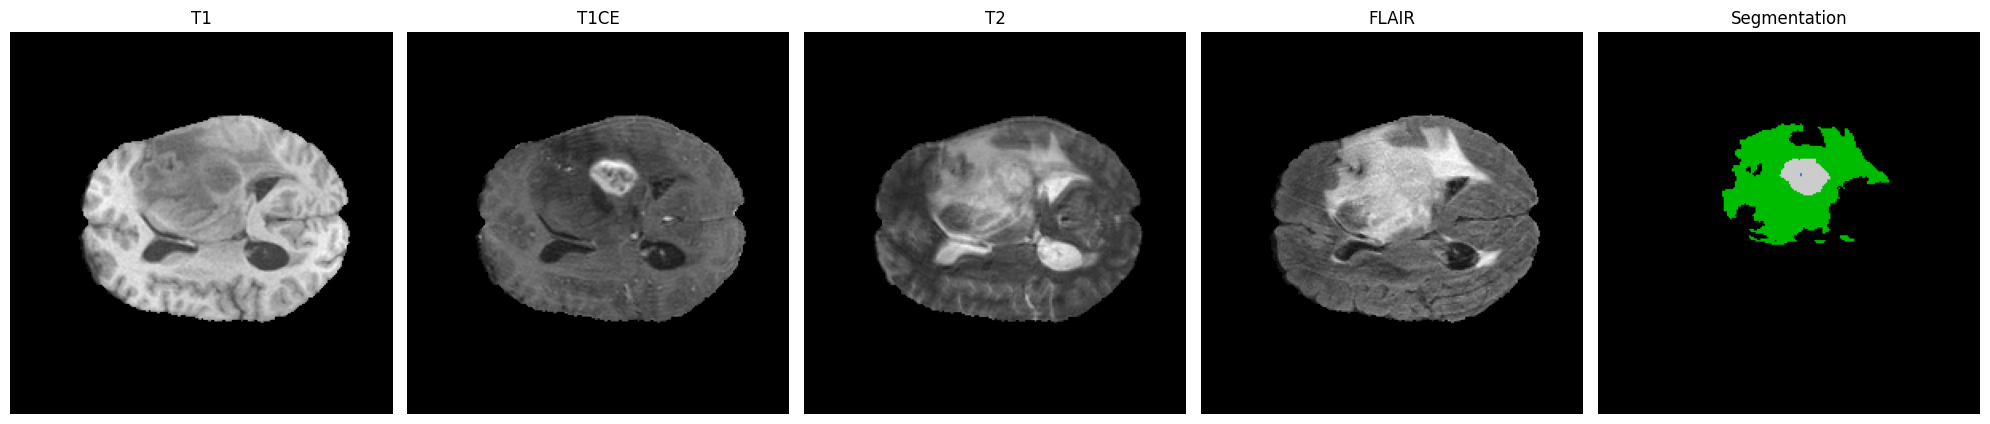

In [ ]:
#visualize

slice_idx = t1.shape[2] // 2

print("\nVisualizing slice:", slice_idx)

# -----------------------------
# Plot modalities
# -----------------------------
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(t1[:, :, slice_idx], cmap='gray')
axes[0].set_title("T1")

axes[1].imshow(t1ce[:, :, slice_idx], cmap='gray')
axes[1].set_title("T1CE")

axes[2].imshow(t2[:, :, slice_idx], cmap='gray')
axes[2].set_title("T2")

axes[3].imshow(flair[:, :, slice_idx], cmap='gray')
axes[3].set_title("FLAIR")

axes[4].imshow(seg[:, :, slice_idx], cmap='nipy_spectral')
axes[4].set_title("Segmentation")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# to rename the 355 folder
# print(patients[354])
# print(os.listdir(patients[354]))
# print(os.listdir(patients[355]))
# print(patients[355])

# patient_change = patients[354]

# old_path = os.path.join(patient_change, "W39_1998.09.19_Segm.nii")
# new_path = os.path.join(patient_change, "BraTS20_Training_355_seg.nii")

# os.rename(old_path, new_path)
# print(os.listdir(patients[354]))

# read only so cannot edit
# drop instead

import os

patients = [
    p for p in patients
    if os.path.exists(
        os.path.join(p, f"{os.path.basename(p)}_seg.nii")
    )
]
print("Total patients:", len(patients))

Total patients: 368


In [ ]:
from sklearn.model_selection import train_test_split

train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_patients))
print("Validation:", len(val_patients))
print("Test:", len(test_patients))

Train: 257
Validation: 55
Test: 56


In [ ]:
import os
import glob
import nibabel as nib
import numpy as np

def load_patient(patient_path):

    patient_id = os.path.basename(patient_path)

    flair = nib.load(
        os.path.join(patient_path, f"{patient_id}_flair.nii")
    ).get_fdata()

    t1 = nib.load(
        os.path.join(patient_path, f"{patient_id}_t1.nii")
    ).get_fdata()

    t1ce = nib.load(
        os.path.join(patient_path, f"{patient_id}_t1ce.nii")
    ).get_fdata()

    t2 = nib.load(
        os.path.join(patient_path, f"{patient_id}_t2.nii")
    ).get_fdata()

    seg = nib.load(
        os.path.join(patient_path, f"{patient_id}_seg.nii")
    ).get_fdata()

    # stack modalities
    image = np.stack(
        [flair, t1, t1ce, t2],
        axis=0
    )

    # label remap
    seg = seg.astype(np.uint8)
    seg[seg == 4] = 3

    return image, seg

In [ ]:
image, seg = load_patient(train_patients[0])

print("Image shape:", image.shape)
print("Mask shape :", seg.shape)

print("Mask labels:", np.unique(seg))

Image shape: (4, 240, 240, 155)
Mask shape : (240, 240, 155)
Mask labels: [0 1 2 3]


In [ ]:
image, seg = load_patient(train_patients[0])

print("Image shape:", image.shape)

brain_mask = np.any(image != 0, axis=0)

print("Brain voxels:", brain_mask.sum())
print("Total voxels:", brain_mask.size)

print(
    "Background percentage:",
    100 * (1 - brain_mask.sum()/brain_mask.size)
)

Image shape: (4, 240, 240, 155)
Brain voxels: 1850813
Total voxels: 8928000
Background percentage: 79.26956765232975


In [ ]:
image, seg = load_patient(train_patients[0])

brain_mask = np.any(image != 0, axis=0)

coords = np.where(brain_mask)

x_min, x_max = coords[0].min(), coords[0].max()
y_min, y_max = coords[1].min(), coords[1].max()
z_min, z_max = coords[2].min(), coords[2].max()

print("X:", x_min, x_max)
print("Y:", y_min, y_max)
print("Z:", z_min, z_max)

X: 46 193
Y: 40 215
Z: 0 145


In [ ]:
cropped_image = image[
    :,
    x_min:x_max+1,
    y_min:y_max+1,
    z_min:z_max+1
]

cropped_seg = seg[
    x_min:x_max+1,
    y_min:y_max+1,
    z_min:z_max+1
]

print("Original image:", image.shape)
print("Cropped image :", cropped_image.shape)

print("Original seg :", seg.shape)
print("Cropped seg  :", cropped_seg.shape)

Original image: (4, 240, 240, 155)
Cropped image : (4, 148, 176, 146)
Original seg : (240, 240, 155)
Cropped seg  : (148, 176, 146)


In [ ]:
def zscore_normalize(image):
    image = image.copy()

    for c in range(image.shape[0]):

        modality = image[c]

        mask = modality > 0

        mean = modality[mask].mean()
        std = modality[mask].std()

        modality[mask] = (
            modality[mask] - mean
        ) / (std + 1e-8)

        image[c] = modality

    return image

In [ ]:
cropped_image = zscore_normalize(cropped_image)

for c, name in enumerate(
    ["FLAIR", "T1", "T1CE", "T2"]
):
    modality = cropped_image[c]

    mask = modality != 0

    print(
        name,
        "mean:",
        modality[mask].mean(),
        "std:",
        modality[mask].std()
    )

FLAIR mean: 4.2260755492991074e-17 std: 0.9999999998868411
T1 mean: -1.5086082449493166e-16 std: 0.9999999999301665
T1CE mean: 8.234072718667606e-17 std: 0.9999999999429188
T2 mean: 1.464383527032409e-16 std: 0.9999999999238067


In [ ]:
def preprocess_patient(patient_path):

    image, seg = load_patient(patient_path)

    # ------------------
    # crop
    # ------------------
    brain_mask = np.any(image != 0, axis=0)

    coords = np.where(brain_mask)

    x_min, x_max = coords[0].min(), coords[0].max()
    y_min, y_max = coords[1].min(), coords[1].max()
    z_min, z_max = coords[2].min(), coords[2].max()

    image = image[
        :,
        x_min:x_max+1,
        y_min:y_max+1,
        z_min:z_max+1
    ]

    seg = seg[
        x_min:x_max+1,
        y_min:y_max+1,
        z_min:z_max+1
    ]

    # ------------------
    # normalize
    # ------------------
    image = zscore_normalize(image)

    return image, seg

In [ ]:
image, seg = preprocess_patient(
    train_patients[0]
)

print(image.shape)
print(seg.shape)

print(np.unique(seg))

(4, 148, 176, 146)
(148, 176, 146)
[0 1 2 3]


In [ ]:
image, seg = preprocess_patient(train_patients[0])

tumor_slices = 0

for z in range(seg.shape[2]):
    if np.any(seg[:, :, z] > 0):
        tumor_slices += 1

print("Total slices:", seg.shape[2])
print("Tumor slices:", tumor_slices)
print("Non-tumor slices:", seg.shape[2] - tumor_slices)

Total slices: 146
Tumor slices: 68
Non-tumor slices: 78


In [ ]:
for i in range(5):

    image, seg = preprocess_patient(train_patients[i])

    tumor_slices = sum(
        np.any(seg[:, :, z] > 0)
        for z in range(seg.shape[2])
    )

    print(
        f"Patient {i}: "
        f"{tumor_slices}/{seg.shape[2]} tumor slices"
    )

Patient 0: 68/146 tumor slices
Patient 1: 45/141 tumor slices
Patient 2: 80/139 tumor slices
Patient 3: 80/139 tumor slices
Patient 4: 43/141 tumor slices


In [ ]:
from torch.utils.data import Dataset
import torch

class BraTS2DDataset(Dataset):

    def __init__(self, patient_list):

        self.samples = []

        for patient in patient_list:

            image, seg = preprocess_patient(patient)

            for z in range(seg.shape[2]):

                # keep only slices containing tumor
                if np.any(seg[:, :, z] > 0):

                    self.samples.append(
                        (
                            image[:, :, :, z],
                            seg[:, :, z]
                        )
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        image, seg = self.samples[idx]

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        seg = torch.tensor(
            seg,
            dtype=torch.long
        )

        return image, seg

In [ ]:
small_dataset = BraTS2DDataset(
    train_patients[:5]
)

print("Total slices:", len(small_dataset))

Total slices: 316


In [ ]:
image, mask = small_dataset[0]

print("Image shape:", image.shape)
print("Mask shape :", mask.shape)

print("Image dtype:", image.dtype)
print("Mask dtype :", mask.dtype)

print("Labels:", torch.unique(mask))

Image shape: torch.Size([4, 148, 176])
Mask shape : torch.Size([148, 176])
Image dtype: torch.float32
Mask dtype : torch.int64
Labels: tensor([0, 2])


In [ ]:
for i in range(10):

    image, seg = preprocess_patient(train_patients[i])

    print(image.shape)

(4, 148, 176, 146)
(4, 134, 167, 141)
(4, 140, 180, 139)
(4, 157, 164, 139)
(4, 131, 173, 141)
(4, 139, 177, 134)
(4, 133, 167, 137)
(4, 146, 163, 139)
(4, 136, 159, 137)
(4, 132, 164, 139)


In [ ]:
import cv2
print(cv2.__version__)

4.13.0


In [ ]:
def resize_image_slice(image_slice, size=(128, 128)):
    """
    image_slice: (4, H, W)
    returns: (4, 128, 128)
    """

    resized_channels = []

    for c in range(image_slice.shape[0]):

        resized = cv2.resize(
            image_slice[c],
            size,
            interpolation=cv2.INTER_LINEAR
        )

        resized_channels.append(resized)

    return np.stack(resized_channels, axis=0)

In [ ]:
def resize_mask_slice(mask_slice, size=(128, 128)):
    """
    mask_slice: (H, W)
    returns: (128, 128)
    """

    return cv2.resize(
        mask_slice.astype(np.uint8),
        size,
        interpolation=cv2.INTER_NEAREST
    )

In [ ]:
image, seg = preprocess_patient(train_patients[0])

z = 100

image_slice = image[:, :, :, z]
mask_slice = seg[:, :, z]

print("Before:")
print(image_slice.shape)
print(mask_slice.shape)

image_slice = resize_image_slice(image_slice)
mask_slice = resize_mask_slice(mask_slice)

print("\nAfter:")
print(image_slice.shape)
print(mask_slice.shape)

print("\nLabels:")
print(np.unique(mask_slice))

Before:
(4, 148, 176)
(148, 176)

After:
(4, 128, 128)
(128, 128)

Labels:
[0 1 2 3]


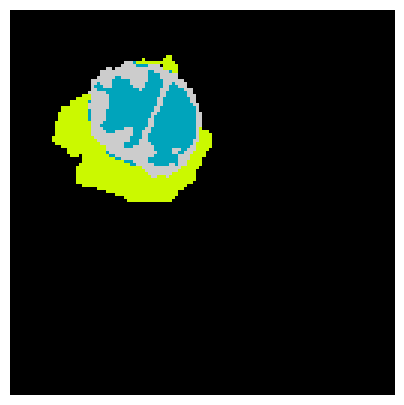

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(mask_slice, cmap="nipy_spectral")
plt.axis("off")
plt.show()

In [ ]:
class BraTS2DDataset(Dataset):

    def __init__(self, patient_list):

        self.samples = []

        for patient in patient_list:

            image, seg = preprocess_patient(patient)

            for z in range(seg.shape[2]):

                if np.any(seg[:, :, z] > 0):

                    image_slice = image[:, :, :, z]
                    mask_slice = seg[:, :, z]

                    image_slice = resize_image_slice(
                        image_slice
                    )

                    mask_slice = resize_mask_slice(
                        mask_slice
                    )

                    self.samples.append(
                        (
                            image_slice,
                            mask_slice
                        )
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        image, mask = self.samples[idx]

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask

In [ ]:
train_dataset = BraTS2DDataset(
    train_patients[:10]
)

print(len(train_dataset))

608


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

In [ ]:
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks :", masks.shape)

print(images.dtype)
print(masks.dtype)

Images: torch.Size([8, 4, 128, 128])
Masks : torch.Size([8, 128, 128])
torch.float32
torch.int64


In [ ]:
# BraTS Patient
# ↓
# Load NIfTI files
# ↓
# Stack 4 modalities
# ↓
# Remap labels (0,1,2,4 → 0,1,2,3)
# ↓
# Crop brain region
# ↓
# Z-score normalize
# ↓
# Extract tumor slices
# ↓
# Resize to 128×128
# ↓
# Convert to tensors
# ↓
# DataLoader
# ↓
# Batch shape = [B,4,128,128]

In [ ]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
block = DoubleConv(4, 64)

x = torch.randn(8, 4, 128, 128)

y = block(x)

print(y.shape)

torch.Size([8, 64, 128, 128])


In [ ]:
class Down(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

    def forward(self, x):

        skip = self.conv(x)

        x = self.pool(skip)

        return skip, x

In [ ]:
down = Down(4, 64)

x = torch.randn(
    8,
    4,
    128,
    128
)

skip, pooled = down(x)

print("Skip :", skip.shape)
print("Pool :", pooled.shape)

Skip : torch.Size([8, 64, 128, 128])
Pool : torch.Size([8, 64, 64, 64])


In [ ]:
class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = Down(4, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 512)

        self.bottleneck = DoubleConv(
            512,
            1024
        )

    def forward(self, x):

        s1, x = self.down1(x)
        s2, x = self.down2(x)
        s3, x = self.down3(x)
        s4, x = self.down4(x)

        x = self.bottleneck(x)

        return x, (s1, s2, s3, s4)

In [ ]:
encoder = Encoder()

x = torch.randn(
    8,
    4,
    128,
    128
)

bottleneck, skips = encoder(x)

print("Bottleneck:", bottleneck.shape)

for i, s in enumerate(skips, start=1):
    print(f"Skip {i}:", s.shape)

Bottleneck: torch.Size([8, 1024, 8, 8])
Skip 1: torch.Size([8, 64, 128, 128])
Skip 2: torch.Size([8, 128, 64, 64])
Skip 3: torch.Size([8, 256, 32, 32])
Skip 4: torch.Size([8, 512, 16, 16])


In [ ]:
class Up(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels * 2,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        x = torch.cat(
            [skip, x],
            dim=1
        )

        x = self.conv(x)

        return x

In [ ]:
up = Up(
    in_channels=1024,
    out_channels=512
)

x = torch.randn(
    8,
    1024,
    8,
    8
)

skip = torch.randn(
    8,
    512,
    16,
    16
)

y = up(x, skip)

print(y.shape)

torch.Size([8, 512, 16, 16])


In [ ]:
class UNet(nn.Module):

    def __init__(self,
                 in_channels=4,
                 num_classes=4):

        super().__init__()

        # Encoder
        self.down1 = Down(in_channels, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(
            512,
            1024
        )

        # Decoder
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        # Final classifier
        self.final_conv = nn.Conv2d(
            64,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        s1, x = self.down1(x)
        s2, x = self.down2(x)
        s3, x = self.down3(x)
        s4, x = self.down4(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        x = self.up1(x, s4)
        x = self.up2(x, s3)
        x = self.up3(x, s2)
        x = self.up4(x, s1)

        # Output
        x = self.final_conv(x)

        return x

In [ ]:
model = UNet()

x = torch.randn(
    8,
    4,
    128,
    128
)

y = model(x)

print(y.shape)

torch.Size([8, 4, 128, 128])


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = UNet().to(device)

images, masks = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)

Input : torch.Size([8, 4, 128, 128])
Output: torch.Size([8, 4, 128, 128])


In [ ]:
criterion = nn.CrossEntropyLoss()

loss = criterion(
    outputs,
    masks.to(device)
)

print(loss.item())

1.2853765487670898


In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

optimizer.zero_grad()

loss.backward()

optimizer.step()

print("One training step completed")

One training step completed


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

model.train()

running_loss = 0

for images, masks in train_loader:

    images = images.to(device)
    masks = masks.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(
        outputs,
        masks
    )

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

avg_loss = running_loss / len(train_loader)

print("Average Loss:", avg_loss)

Average Loss: 0.5820986712841612


In [ ]:
model.eval()

images, masks = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

preds = torch.argmax(outputs, dim=1)

print(preds.shape)

torch.Size([8, 128, 128])


In [ ]:
sample_idx = 0

image = images[sample_idx].cpu().numpy()
gt_mask = masks[sample_idx].numpy()
pred_mask = preds[sample_idx].cpu().numpy()

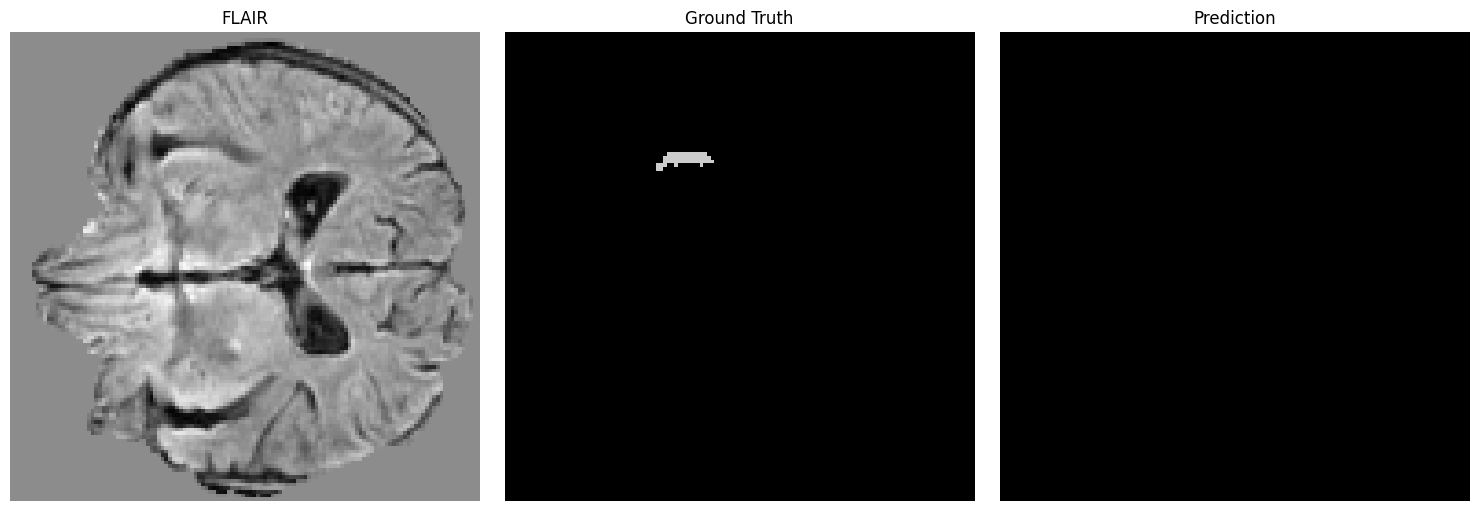

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# FLAIR channel
axes[0].imshow(image[0], cmap="gray")
axes[0].set_title("FLAIR")

axes[1].imshow(gt_mask, cmap="nipy_spectral")
axes[1].set_title("Ground Truth")

axes[2].imshow(pred_mask, cmap="nipy_spectral")
axes[2].set_title("Prediction")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def dice_score(pred, target, smooth=1e-5):

    pred = pred.float()
    target = target.float()

    intersection = (pred * target).sum()

    return (
        2 * intersection + smooth
    ) / (
        pred.sum() + target.sum() + smooth
    )

In [ ]:
pred_binary = (pred_mask > 0)
gt_binary = (gt_mask > 0)

dice = dice_score(
    torch.tensor(pred_binary),
    torch.tensor(gt_binary)
)

print("Dice:", dice.item())

Dice: 2.2222215534384304e-07


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, masks in train_loader:

        # Move data to GPU
        images = images.to(device)
        masks = masks.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, masks)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}"
    )

Epoch 1/5 | Loss: 0.1429
Epoch 2/5 | Loss: 0.1092
Epoch 3/5 | Loss: 0.0892
Epoch 4/5 | Loss: 0.0734
Epoch 5/5 | Loss: 0.0639


In [ ]:
print(len(train_dataset))

608


In [ ]:
model.eval()

images, masks = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

preds = torch.argmax(outputs, dim=1)

sample_idx = 0

image = images[sample_idx].cpu().numpy()
gt_mask = masks[sample_idx].numpy()
pred_mask = preds[sample_idx].cpu().numpy()

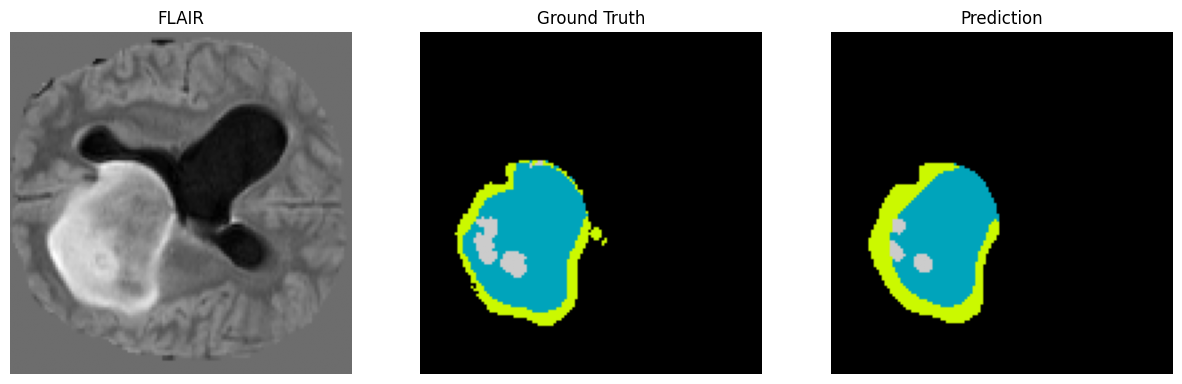

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image[0], cmap="gray")
axes[0].set_title("FLAIR")

axes[1].imshow(gt_mask, cmap="nipy_spectral")
axes[1].set_title("Ground Truth")

axes[2].imshow(pred_mask, cmap="nipy_spectral")
axes[2].set_title("Prediction")

for ax in axes:
    ax.axis("off")

plt.show()

In [ ]:
val_dataset = BraTS2DDataset(
    val_patients
)

print("Validation slices:", len(val_dataset))

Validation slices: 3581


In [ ]:
val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

In [ ]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            running_loss += loss.item()

    return running_loss / len(loader)

In [ ]:
val_loss = validate(
    model,
    val_loader,
    criterion,
    device
)

print("Validation Loss:", val_loss)

Validation Loss: 0.10649217804166256


In [ ]:
def dice_score(pred, target, smooth=1e-5):

    pred = pred.float()
    target = target.float()

    intersection = (pred * target).sum()

    dice = (
        2 * intersection + smooth
    ) / (
        pred.sum() + target.sum() + smooth
    )

    return dice

In [ ]:
def evaluate_dice(model, loader, device):

    model.eval()

    dice_total = 0
    count = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            pred_binary = (preds > 0)
            mask_binary = (masks > 0)

            dice = dice_score(
                pred_binary,
                mask_binary
            )

            dice_total += dice.item()
            count += 1

    return dice_total / count

In [ ]:
dice = evaluate_dice(
    model,
    val_loader,
    device
)

print("Validation Dice:", dice)

Validation Dice: 0.7036445719884604


In [ ]:
import torch.nn.functional as F

class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth

    def forward(self, outputs, targets):

        # Convert logits → probabilities
        probs = torch.softmax(outputs, dim=1)

        # Convert masks to one-hot
        targets_onehot = F.one_hot(
            targets,
            num_classes=4
        )

        targets_onehot = targets_onehot.permute(
            0, 3, 1, 2
        ).float()

        intersection = (
            probs * targets_onehot
        ).sum(dim=(0,2,3))

        union = (
            probs.sum(dim=(0,2,3))
            +
            targets_onehot.sum(dim=(0,2,3))
        )

        dice = (
            2 * intersection + self.smooth
        ) / (
            union + self.smooth
        )

        return 1 - dice.mean()

In [ ]:
dice_loss = DiceLoss()

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

outputs = model(images)

loss = dice_loss(
    outputs,
    masks
)

print(loss.item())

0.3367353081703186


In [ ]:
ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss()

In [ ]:
loss = (
    ce_loss(outputs, masks)
    +
    dice_loss(outputs, masks)
)

In [ ]:
print(loss.item())

0.40739017724990845


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = (
            ce_loss(outputs, masks)
            + dice_loss(outputs, masks)
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs}"
        f" | Loss: {avg_loss:.4f}"
    )

Epoch 1/5 | Loss: 0.3557
Epoch 2/5 | Loss: 0.2868
Epoch 3/5 | Loss: 0.2520
Epoch 4/5 | Loss: 0.2400
Epoch 5/5 | Loss: 0.2396


In [ ]:
val_loss = validate(
    model,
    val_loader,
    criterion,
    device
)

val_dice = evaluate_dice(
    model,
    val_loader,
    device
)

print("Validation Dice:", val_dice)

print("Validation Loss:", val_loss)

Validation Dice: 0.7173087184703533
Validation Loss: 0.19795583189937002


In [ ]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 56.4 MB/s eta 0:00:00


In [ ]:
import monai

print(monai.__version__)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


1.5.2


In [ ]:
from monai.networks.nets import UNet

model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

In [ ]:
x = torch.randn(
    1,
    4,
    128,
    128,
    128
).to(device)

y = model(x)

print(y.shape)

torch.Size([1, 4, 128, 128, 128])


In [ ]:
import os
import glob
import cv2
import nibabel as nib
import numpy as np
import torch

from torch.utils.data import Dataset


class BraTS3DDataset(Dataset):

    def __init__(self, patients, target_size=(128, 128, 128)):
        self.patients = patients
        self.target_size = target_size

    def __len__(self):
        return len(self.patients)

    def zscore_normalize(self, volume):

        mask = volume > 0

        if np.sum(mask) == 0:
            return volume

        mean = volume[mask].mean()
        std = volume[mask].std()

        volume[mask] = (volume[mask] - mean) / (std + 1e-8)

        return volume

    def resize_volume(self, volume, target_size, is_mask=False):

        target_h, target_w, target_d = target_size

        h, w, d = volume.shape

        resized_slices = []

        interpolation = (
            cv2.INTER_NEAREST
            if is_mask
            else cv2.INTER_LINEAR
        )

        # resize each axial slice
        for z in range(d):

            slice_2d = volume[:, :, z]

            slice_resized = cv2.resize(
                slice_2d,
                (target_w, target_h),
                interpolation=interpolation
            )

            resized_slices.append(slice_resized)

        volume = np.stack(resized_slices, axis=-1)

        # resize depth dimension
        resized_depth = []

        for i in range(target_h):

            plane = volume[i, :, :]

            plane_resized = cv2.resize(
                plane,
                (target_d, target_w),
                interpolation=interpolation
            )

            resized_depth.append(plane_resized)

        volume = np.stack(resized_depth, axis=0)

        return volume

    def __getitem__(self, idx):

        patient_path = self.patients[idx]

        flair = nib.load(
            glob.glob(
                os.path.join(patient_path, "*_flair.nii")
            )[0]
        ).get_fdata()

        t1 = nib.load(
            glob.glob(
                os.path.join(patient_path, "*_t1.nii")
            )[0]
        ).get_fdata()

        t1ce = nib.load(
            glob.glob(
                os.path.join(patient_path, "*_t1ce.nii")
            )[0]
        ).get_fdata()

        t2 = nib.load(
            glob.glob(
                os.path.join(patient_path, "*_t2.nii")
            )[0]
        ).get_fdata()

        seg = nib.load(
            glob.glob(
                os.path.join(patient_path, "*_seg.nii")
            )[0]
        ).get_fdata()

        # --------------------------------
        # stack modalities
        # --------------------------------

        image = np.stack(
            [flair, t1, t1ce, t2],
            axis=0
        )

        # --------------------------------
        # crop brain bbox
        # --------------------------------

        brain_mask = np.any(image != 0, axis=0)

        x, y, z = np.where(brain_mask)

        xmin, xmax = x.min(), x.max()
        ymin, ymax = y.min(), y.max()
        zmin, zmax = z.min(), z.max()

        image = image[
            :,
            xmin:xmax+1,
            ymin:ymax+1,
            zmin:zmax+1
        ]

        seg = seg[
            xmin:xmax+1,
            ymin:ymax+1,
            zmin:zmax+1
        ]

        # --------------------------------
        # normalization
        # --------------------------------

        for c in range(4):
            image[c] = self.zscore_normalize(
                image[c]
            )

        # --------------------------------
        # label remap
        # --------------------------------

        seg[seg == 4] = 3

        # --------------------------------
        # resize modalities
        # --------------------------------

        resized_modalities = []

        for c in range(4):

            resized_modalities.append(
                self.resize_volume(
                    image[c],
                    self.target_size,
                    is_mask=False
                )
            )

        image = np.stack(
            resized_modalities,
            axis=0
        )

        seg = self.resize_volume(
            seg,
            self.target_size,
            is_mask=True
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        seg = torch.tensor(
            seg,
            dtype=torch.long
        )

        return image, seg

In [ ]:
train_3d_dataset = BraTS3DDataset(
    train_patients[:10]
)

len(train_3d_dataset)

10

In [ ]:
from torch.utils.data import DataLoader

train_3d_loader = DataLoader(
    train_3d_dataset,
    batch_size=1,
    shuffle=True
)

In [ ]:
images, masks = next(
    iter(train_3d_loader)
)

print(images.shape)
print(masks.shape)

torch.Size([1, 4, 128, 128, 128])
torch.Size([1, 128, 128, 128])


In [ ]:
images, masks = next(iter(train_3d_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)

Input : torch.Size([1, 4, 128, 128, 128])
Output: torch.Size([1, 4, 128, 128, 128])


In [ ]:
from monai.losses import DiceCELoss

loss_fn = DiceCELoss(
    to_onehot_y=True,
    softmax=True
)

In [ ]:
images, masks = next(iter(train_3d_loader))

images = images.to(device)
masks = masks.to(device)

outputs = model(images)

loss = loss_fn(
    outputs,
    masks.unsqueeze(1)
)

print(loss.item())

2.5728096961975098


In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

optimizer.zero_grad()

loss.backward()

optimizer.step()

print("3D training step completed")

3D training step completed


In [ ]:
train_3d_dataset = BraTS3DDataset(
    train_patients[:10]
)

train_3d_loader = DataLoader(
    train_3d_dataset,
    batch_size=1,
    shuffle=True
)

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, masks in train_3d_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(
            outputs,
            masks.unsqueeze(1)
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_3d_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs}"
        f" | Loss: {avg_loss:.4f}"
    )

Epoch 1/5 | Loss: 2.4472
Epoch 2/5 | Loss: 2.3053
Epoch 3/5 | Loss: 2.2367
Epoch 4/5 | Loss: 2.1888
Epoch 5/5 | Loss: 2.1512


In [ ]:
from monai.metrics import (
    DiceMetric,
    HausdorffDistanceMetric
)

In [ ]:
dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

In [ ]:
hd_metric = HausdorffDistanceMetric(
    include_background=False,
    percentile=95
)

In [ ]:
def volumetric_similarity(pred, gt):

    pred_vol = pred.sum().float()
    gt_vol = gt.sum().float()

    vs = 1 - (
        torch.abs(pred_vol - gt_vol)
        /
        (pred_vol + gt_vol + 1e-5)
    )

    return vs.item()

In [ ]:
val_3d_dataset = BraTS3DDataset(
    val_patients[:5]   # start small
)

val_3d_loader = DataLoader(
    val_3d_dataset,
    batch_size=1,
    shuffle=False
)

In [ ]:
model.eval()

images, masks = next(iter(val_3d_loader))
masks = masks.to(device)
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

preds = torch.argmax(outputs, dim=1)

print(preds.shape)
print(masks.shape)

torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])


In [ ]:
def dice_score(pred, target, smooth=1e-5):

    pred = pred.float()
    target = target.float()

    intersection = (pred * target).sum()

    return (
        2 * intersection + smooth
    ) / (
        pred.sum() + target.sum() + smooth
    )

In [ ]:
pred_binary = (preds > 0)
mask_binary = (masks > 0)

dice = dice_score(
    pred_binary,
    mask_binary
)

print("Dice:", dice.item())

Dice: 0.09186089038848877


In [ ]:
from monai.metrics import HausdorffDistanceMetric
import torch.nn.functional as F

In [ ]:
hd95_metric = HausdorffDistanceMetric(
    include_background=False,
    percentile=95
)

In [ ]:
pred_onehot = F.one_hot(
    preds,
    num_classes=4
).permute(0,4,1,2,3).float()

target_onehot = F.one_hot(
    masks,
    num_classes=4
).permute(0,4,1,2,3).float()

In [ ]:
hd95_metric(pred_onehot, target_onehot)

hd95 = hd95_metric.aggregate()

print("HD95:", hd95.item())

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


CompileException: /usr/local/lib/python3.12/dist-packages/cupy/_core/include/cupy/_cccl/thrust/thrust/detail/config/cpp_dialect.h(74): catastrophic error: #error directive: Thrust requires at least C++17. Define CCCL_IGNORE_DEPRECATED_CPP_DIALECT to suppress this message.
  #    error Thrust requires at least C++17. Define CCCL_IGNORE_DEPRECATED_CPP_DIALECT to suppress this message.
       ^

1 catastrophic error detected in the compilation of "/tmp/tmpb57_qeaz/71d18070777c6b594d60916784ff25118c5c11fb.cubin.cu".
Compilation terminated.


In [ ]:
def volumetric_similarity(pred, gt):

    pred_vol = pred.sum().float()
    gt_vol = gt.sum().float()

    return (
        1
        -
        torch.abs(pred_vol - gt_vol)
        /
        (pred_vol + gt_vol + 1e-5)
    )

In [ ]:
vs = volumetric_similarity(
    pred_binary,
    mask_binary
)

print("VS:", vs.item())

VS: 0.11186134815216064


In [ ]:
# DICE
# Hausdorff Distance
# Volumetric Similarity (VS)